# **Feature Engineering and Data Preparation**

##  **Ames Housing Data Set**

The Ames Housing Dataset is a well-known dataset in the field of machine learning and data analysis. It contains various features and attributes of residential homes in Ames, Iowa, USA. The dataset is often used for regression tasks, particularly for predicting housing prices.

Here are some key details about the Ames Housing Dataset:

- Number of Instances: The dataset consists of 2,930 instances or observations.
- Number of Features: There are 79 different features or variables that describe various aspects of the residential properties.
- Target Variable: The target variable in the dataset is the "SalePrice," representing the sale price of the houses.
- Data Types: The features include both numerical and categorical variables, covering a wide range of aspects such as lot size, number of rooms, location, construction, and more.





Let's apply feature engineering and data preparation techniques that we have learned on our Ames Housing Data Set

## **Part 1 – Data Loading and Understanding**

**Step1:** Load the dataset (`Ames_Housing_Data.csv`) into a pandas DataFrame. Display shape and info of the dataset.

In [ ]:
# Do Not Run this

(2930, 81)

In [ ]:
# Do Not Run this

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 81 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   PID              2930 non-null   int64  
 1   MS SubClass      2930 non-null   int64  
 2   MS Zoning        2930 non-null   object 
 3   Lot Frontage     2440 non-null   float64
 4   Lot Area         2930 non-null   int64  
 5   Street           2930 non-null   object 
 6   Alley            198 non-null    object 
 7   Lot Shape        2930 non-null   object 
 8   Land Contour     2930 non-null   object 
 9   Utilities        2930 non-null   object 
 10  Lot Config       2930 non-null   object 
 11  Land Slope       2930 non-null   object 
 12  Neighborhood     2930 non-null   object 
 13  Condition 1      2930 non-null   object 
 14  Condition 2      2930 non-null   object 
 15  Bldg Type        2930 non-null   object 
 16  House Style      2930 non-null   object 
 17  Overall Qual  

**Step2:** Create a heatmap of the correlation matrix.

<Axes: >

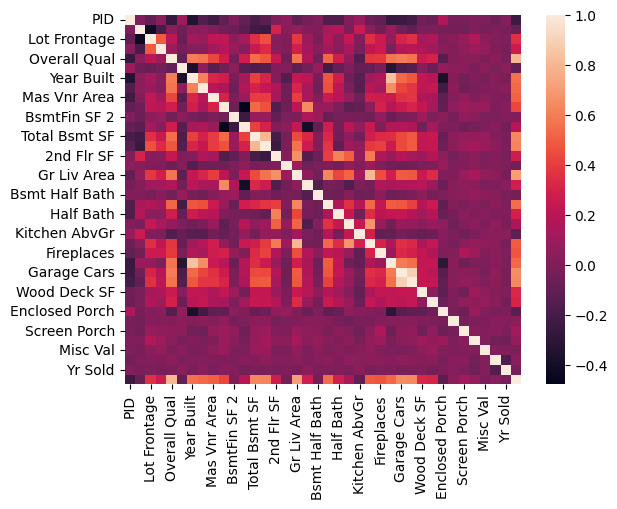

In [ ]:
# Do Not Run this

**Step3:** Generate a sorted list of correlation coefficients

In [ ]:
# Do Not Run this

,SalePrice
PID,-0.246521
Enclosed Porch,-0.128787
Kitchen AbvGr,-0.119814
Overall Cond,-0.101697
MS SubClass,-0.085092
Low Qual Fin SF,-0.037660
Bsmt Half Bath,-0.035835
Yr Sold,-0.030569
Misc Val,-0.015691
BsmtFin SF 2,0.005891


**Step4:** Create a scatter plot of the feature with the highest positive correlation and the target.

Text(0.5, 1.0, 'Overall Quality vs. Sale Price')

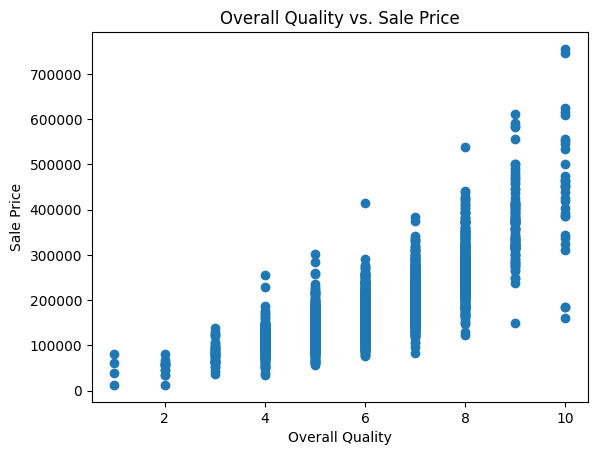

In [ ]:
# Do Not Run this

**Step5:** Create a  scatter plot of the feature with the second highest positive correlation and the target.

Text(0.5, 1.0, 'Gross Living Area vs. Sale Price')

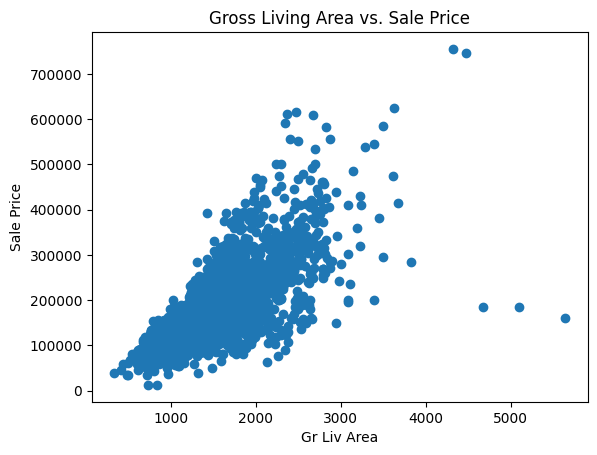

In [ ]:
# Do Not Run this

Feel free to add more exploratory data analysis to know the data better.

<br><br>

## **Part 2 – Outlier Detection and Handling**



We'll start by generating a box plot for the `SalePrice` column to visually identify its distribution and potential outliers. This provides an initial visual assessment of extreme values in our target variable.

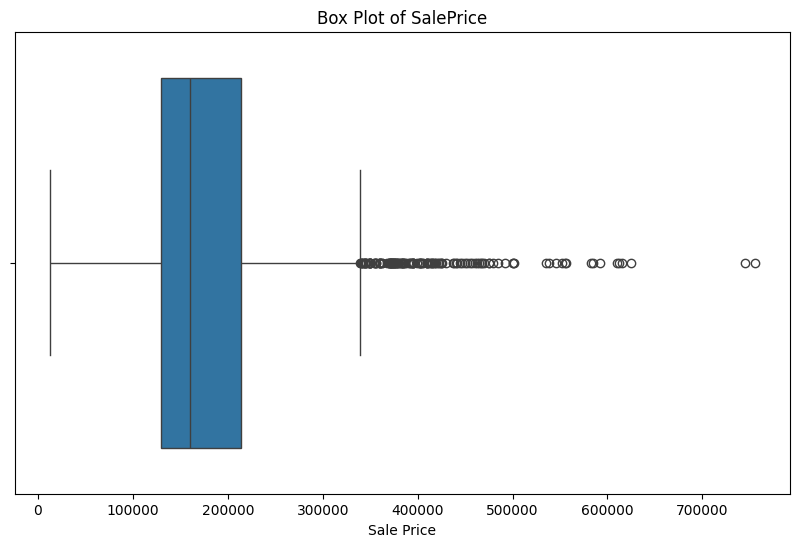

In [ ]:
# Do Not Run this

The box plot for `SalePrice` clearly shows some statistical outliers. While these points are statistically extreme, it's important to consider if they make sense in a real-world context. To evaluate specific cases, especially those that might distort the relationship between key features, let's plot `Gross Living Area` (which has a high correlation with sale) against `SalePrice` again. This will help us determine whether these particular extreme values should be kept or removed based on their joint behavior.

Text(0.5, 1.0, 'Gross Living Area vs. Sale Price')

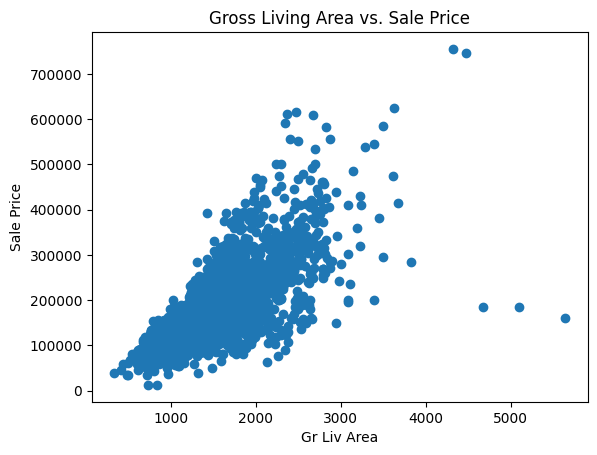

In [ ]:
# Do Not Run this

Applying domain knowledge, we observe two properties with `SalePrice` exceeding `$700,000`. While these points appear as statistical outliers in the `SalePrice` distribution, their unusually high `Gr Liv Area` suggests they could be legitimate high-value properties rather than data errors. Their extreme values might simply reflect a sparse representation of such large and expensive homes in the dataset, rather than being inherently anomalous. Therefore, we should consider retaining these, as they likely represent a valid segment of the market.

However by closely looking at the same plot we can identify another 3 point all the way to the left of the plot that appear to have large `Gr Liv Area` but low price these may not make sense, lets plot the box plot for `Gr Liv Area`

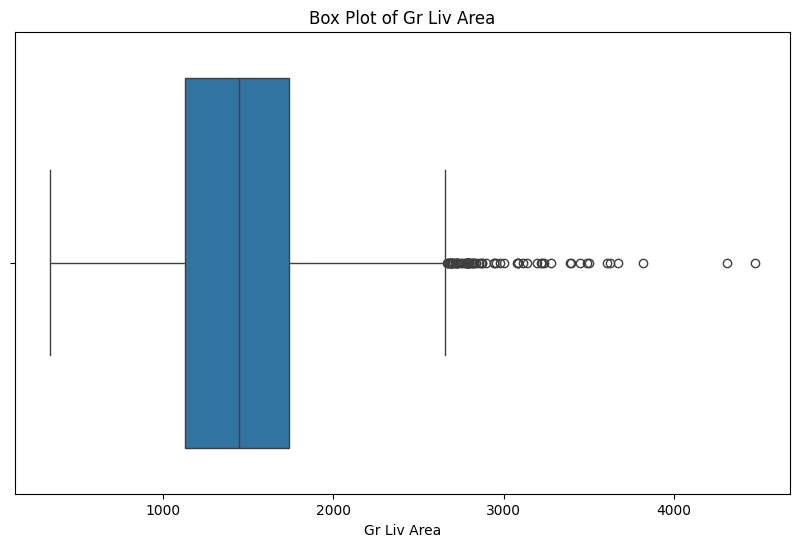

In [ ]:
# Do Not Run this


Let's explicitly identify and remove the 3 problematic outliers where 'Gr Liv Area' was exceptionally large (> 4000 sq ft) and 'SalePrice' was relatively low (< $400,000). This removal is based on the joint, domain-specific criteria that these points severely distort the expected relationship between living area and sale price, rather than solely relying on '`Gr Liv Area`' plot.

In [ ]:
# Do Not Run this

Number of specific outliers to remove: 3


,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,Utilities,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
1498,908154235,60,RL,313.0,63887,Pave,NaN,IR3,Bnk,AllPub,...,480,Gd,NaN,NaN,0,1,2008,New,Partial,160000
2180,908154195,20,RL,128.0,39290,Pave,NaN,IR1,Bnk,AllPub,...,0,NaN,NaN,Elev,17000,10,2007,New,Partial,183850
2181,908154205,60,RL,130.0,40094,Pave,NaN,IR1,Bnk,AllPub,...,0,NaN,NaN,NaN,0,10,2007,New,Partial,184750


In [ ]:
# Get the indices of the outliers to remove


# Drop these rows from the DataFrame



In [ ]:
# Do Not Run this

DataFrame shape after removing 3 outliers: (2927, 81)


Let's verify Outlier Removal. Re-generate scatter plots of '`Gr Liv Area' vs. 'SalePrice`' to visually confirm the successful removal of the 3 specific outliers and to see the improved relationship between these features.

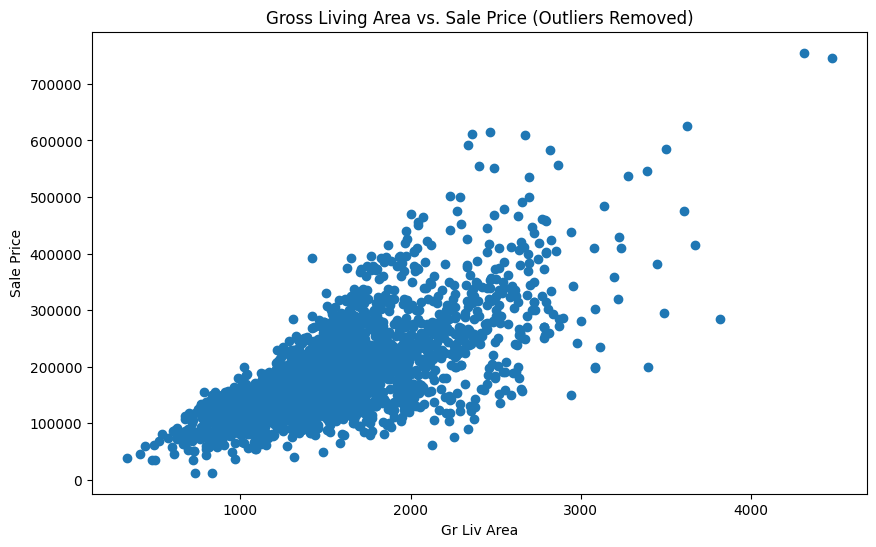

In [ ]:
# Do Not Run this

Feel free to explore further methods for outlier detection and handling.'

<br><br>

##  **Part 3 - Dealing with Missing Data**

We already reviewed Pandas operations for missing data, now let's apply this to clean a real data file.

Keep in mind, there is no 100% correct way of doing this, and this notebook just serves as an example of some reasonable approaches to take on this data.


### **Removing the PID**

We already have an index, so we don't need the PID unique identifier for the regression we will perform later on.

In [ ]:
len(df.columns)

81

In [ ]:
len(df.columns)

80

### **Identifying NaN Features**

Check the nulls

In [ ]:
# Do Not Run this

,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,Utilities,Lot Config,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,False,False,False,False,False,True,False,False,False,False,...,False,True,True,True,False,False,False,False,False,False
1,False,False,False,False,False,True,False,False,False,False,...,False,True,False,True,False,False,False,False,False,False
2,False,False,False,False,False,True,False,False,False,False,...,False,True,True,False,False,False,False,False,False,False
3,False,False,False,False,False,True,False,False,False,False,...,False,True,True,True,False,False,False,False,False,False
4,False,False,False,False,False,True,False,False,False,False,...,False,True,False,True,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2925,False,False,False,False,False,True,False,False,False,False,...,False,True,False,True,False,False,False,False,False,False
2926,False,False,True,False,False,True,False,False,False,False,...,False,True,False,True,False,False,False,False,False,False
2927,False,False,False,False,False,True,False,False,False,False,...,False,True,False,False,False,False,False,False,False,False
2928,False,False,False,False,False,True,False,False,False,False,...,False,True,True,True,False,False,False,False,False,False


How many rows are missing values? Given the large number of columns, the complete result might not be immediately visible.

In [ ]:
# Do Not Run this

,0
MS SubClass,0
MS Zoning,0
Lot Frontage,490
Lot Area,0
Street,0
...,...
Mo Sold,0
Yr Sold,0
Sale Type,0
Sale Condition,0


What is the percentage of missing data per feature? Given the large number of columns, the complete result might not be immediately visible.

In [ ]:
# Do Not Run this

,0
MS SubClass,0.00000
MS Zoning,0.00000
Lot Frontage,16.74069
Lot Area,0.00000
Street,0.00000
...,...
Mo Sold,0.00000
Yr Sold,0.00000
Sale Type,0.00000
Sale Condition,0.00000


Create a function of that reports the percentage of missing data and sort them.

In [ ]:
# Do Not Run this

,0
Total Bsmt SF,0.034165
Bsmt Unf SF,0.034165
BsmtFin SF 2,0.034165
Electrical,0.034165
BsmtFin SF 1,0.034165
Garage Area,0.034165
Garage Cars,0.034165
Bsmt Full Bath,0.068329
Bsmt Half Bath,0.068329
Mas Vnr Area,0.785787


Create a bar plot showing the features sorted by the amount of missing data.

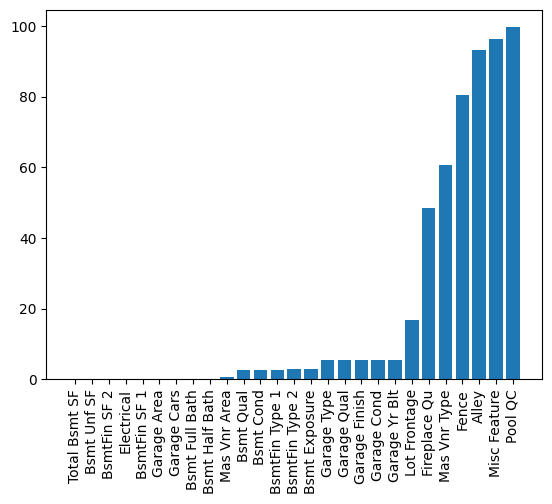

In [ ]:
# Do Not Run this

### **Removing Features or Removing Rows**

If only a few rows relative to the size of your dataset are missing some values, then it might just be a good idea to drop those rows. What does this cost you in terms of performace? It essentialy removes potential training/testing data, but if its only a few rows, its unlikely to change performance.

Sometimes it is a good idea to remove a feature entirely if it has too many null values. However, you should carefully consider why it has so many null values, in certain situations null could just be used as a separate category.

Take for example a feature column for the number of cars that can fit into a garage. Perhaps if there is no garage then there is a null value, instead of a zero. It probably makes more sense to quickly fill the null values in this case with a zero instead of a null. Only you can decide based off your domain expertise and knowledge of the data set!

### **Working based on Rows Missing Data**

#### **Filling in Data or Dropping Data?**

Let's explore how to choose to remove or fill in missing data for rows that are missing some data. Let's choose some threshold where we decide it is ok to drop a row if its missing some data (instead of attempting to fill in that missing data point). We will choose 1% as our threshold. This means if less than 1% of the rows are missing this feature, we will consider just dropping that row, instead of dealing with the feature itself.

There is no right answer here, just use common sense and your domain knowledge of the dataset, obviously you don't want to drop a very high threshold like 50% , you should also explore correlation to the dataset, maybe it makes sense to drop the feature instead.

Based on the text description of the features, you will see that most of this missing data is actually NaN on purpose as a placeholder for 0 or "none".

**Example of Filling in Data : Basement Columns**

(0.0, 1.0)

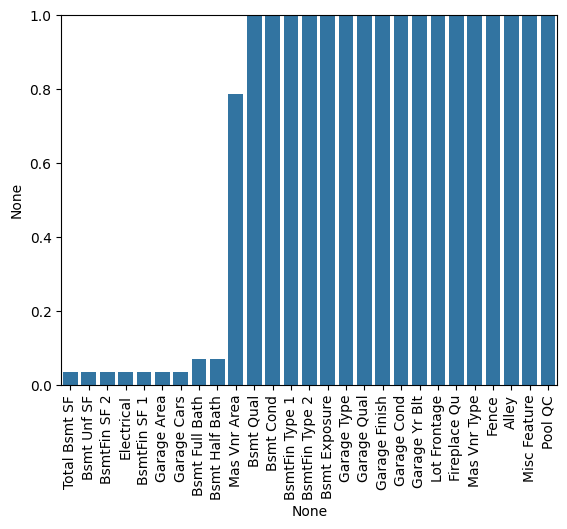

In [ ]:
sns.barplot(x=percent_nan.index,y=percent_nan)
plt.xticks(rotation=90);

# Set 1% Threshold
plt.ylim(0,1)

Let's drop or fill the rows based on this data. You could either manually fill in the data (especially the Basement data based on the description text file) OR you could simply drop the row and not consider it.

What are the features that have percent missing less than 1%

In [ ]:
# Do Not Run this

,0
Total Bsmt SF,0.034165
Bsmt Unf SF,0.034165
BsmtFin SF 2,0.034165
Electrical,0.034165
BsmtFin SF 1,0.034165
Garage Area,0.034165
Garage Cars,0.034165
Bsmt Full Bath,0.068329
Bsmt Half Bath,0.068329
Mas Vnr Area,0.785787


How many rows is this number 0.034165 (let's use 'Total Bsmt SF' to explore)?





In [ ]:
100/len(df)

0.0341646737273659

In [ ]:
df[df['Total Bsmt SF'].isnull()]

,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,Utilities,Lot Config,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
1341,20,RM,99.0,5940,Pave,NaN,IR1,Lvl,AllPub,FR3,...,0,NaN,MnPrv,NaN,0,4,2008,ConLD,Abnorml,79000


How about 'Bsmt Half Bath'?

In [ ]:
# Do Not Run this

,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,Utilities,Lot Config,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
1341,20,RM,99.0,5940,Pave,NaN,IR1,Lvl,AllPub,FR3,...,0,NaN,MnPrv,NaN,0,4,2008,ConLD,Abnorml,79000
1497,20,RL,123.0,47007,Pave,NaN,IR1,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,7,2008,WD,Normal,284700


<br>

Let's look at the description file that came with the data

In [ ]:
with open('Ames_Housing_Feature_Description.txt') as f:
    print(f.read())

MSSubClass: Identifies the type of dwelling involved in the sale.	

        20	1-STORY 1946 & NEWER ALL STYLES
        30	1-STORY 1945 & OLDER
        40	1-STORY W/FINISHED ATTIC ALL AGES
        45	1-1/2 STORY - UNFINISHED ALL AGES
        50	1-1/2 STORY FINISHED ALL AGES
        60	2-STORY 1946 & NEWER
        70	2-STORY 1945 & OLDER
        75	2-1/2 STORY ALL AGES
        80	SPLIT OR MULTI-LEVEL
        85	SPLIT FOYER
        90	DUPLEX - ALL STYLES AND AGES
       120	1-STORY PUD (Planned Unit Development) - 1946 & NEWER
       150	1-1/2 STORY PUD - ALL AGES
       160	2-STORY PUD - 1946 & NEWER
       180	PUD - MULTILEVEL - INCL SPLIT LEV/FOYER
       190	2 FAMILY CONVERSION - ALL STYLES AND AGES

MSZoning: Identifies the general zoning classification of the sale.
		
       A	Agriculture
       C	Commercial
       FV	Floating Village Residential
       I	Industrial
       RH	Residential High Density
       RL	Residential Low Density
       RP	Residential Low Density Park 
       RM

**Filling in data based on column names.**

There are 2 types of basement features, numerical and string descriptives.

The numerical basement columns:

For all 'BsmtFin SF 1', 'BsmtFin SF 2', 'Bsmt Unf SF','Total Bsmt SF', 'Bsmt Full Bath', 'Bsmt Half Bath' they are numerical columns so perhaps a good choice for Null in this case is 0.

Replace Nulls in this columns with zero

For Bsmt Qual', 'Bsmt Cond', 'Bsmt Exposure', 'BsmtFin Type 1', 'BsmtFin Type 2', they are string columns, perhaps a good choice for Null in this case is None.

Replace Nulls in this columns with None

Let's recalculate the missing percentage and plot again

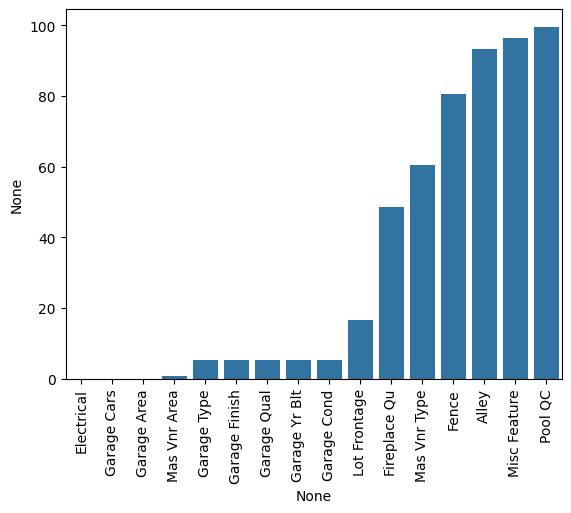

In [ ]:
# Do Not Run this

### **Dropping Rows**

A few of these features appear that it is just one or two rows missing the data. Based on our description .txt file of the dataset, we could also fill in these data points easily, and that is the more correct approach, but here we show how to drop in case you find yourself in a situation where it makes more sense to drop a row, based on missing column features.


    df.dropna() ---
        subset : array-like, optional
                Labels along other axis to consider, e.g. if you are dropping rows
                these would be a list of columns to include.

Drop 'Electrical' and 'Garage Cars'

Let's recalculate the missing percentage and plot again

(0.0, 1.0)

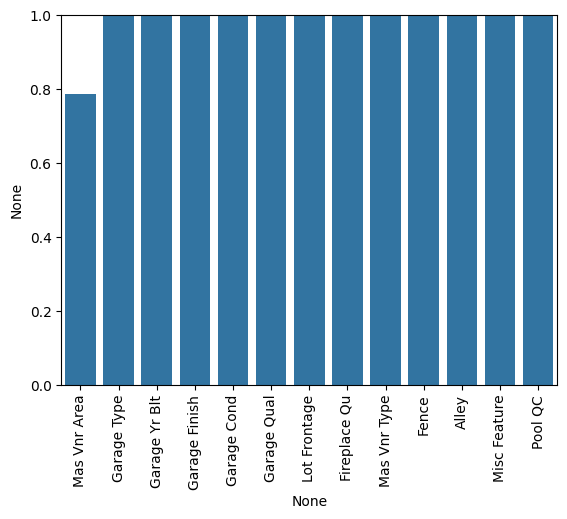

In [ ]:
# Do Not Run this

**Mas Vnr Feature**

Based on the Description Text File, Mas Vnr Type and Mas Vnr Area being missing (NaN) is likely to mean the house simply just doesn't have a masonry veneer, in which case, we will fill in this data as we did before.

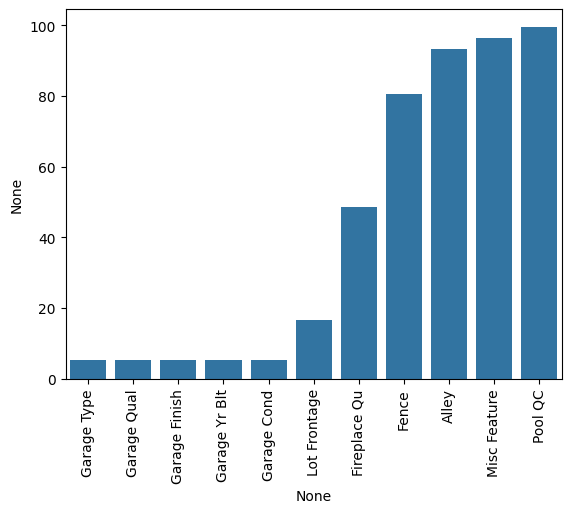

In [ ]:
# Do Not Run this

### **Filling In Missing Column Data**

Our previous approaches were based more on rows missing data, now we will take an approach based on the column features themselves, since larger percentages of the data appears to be missing.

**Garage Columns**

Based on the data description, these NaN seem to indicate no garage, so we will substitute with "None" or 0.

In [ ]:
# Do Not Run this

,Garage Type,Garage Finish,Garage Qual,Garage Cond
0,Attchd,Fin,TA,TA
1,Attchd,Unf,TA,TA
2,Attchd,Unf,TA,TA
3,Attchd,Fin,TA,TA
4,Attchd,Fin,TA,TA
...,...,...,...,...
2925,Detchd,Unf,TA,TA
2926,Attchd,Unf,TA,TA
2927,NaN,NaN,NaN,NaN
2928,Attchd,RFn,TA,TA


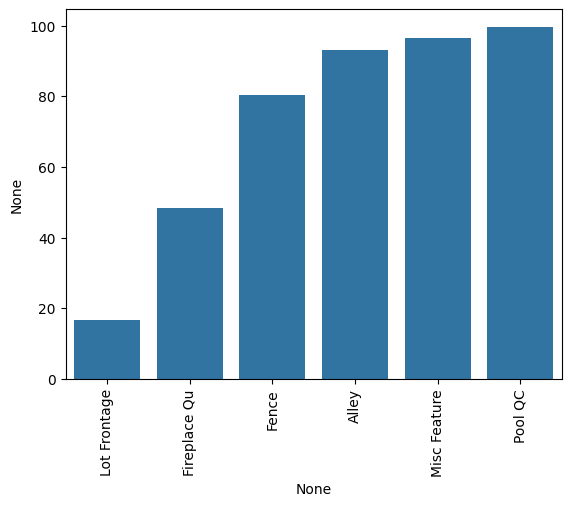

In [ ]:
# Do Not Run this

### **Dropping Feature Columns**

Sometimes you may want to take the approach that above a certain missing percentage threshold, you will simply remove the feature from all the data. For example if 99% of rows are missing a feature, it will not be predictive, since almost all the data does not have any value for it. In our particular data set, many of these high percentage NaN features are actually plasceholders for "none" or 0. But for the sake of showing variations on dealing with missing data, we will remove these features, instead of filling them in with the appropriate value.

In [ ]:
percent_nan.index

Index(['Lot Frontage', 'Fireplace Qu', 'Fence', 'Alley', 'Misc Feature',
       'Pool QC'],
      dtype='object')

In [ ]:
# Do Not Run this

,Lot Frontage,Fireplace Qu,Fence,Alley,Misc Feature,Pool QC
0,141.0,Gd,NaN,NaN,NaN,NaN
1,80.0,NaN,MnPrv,NaN,NaN,NaN
2,81.0,NaN,NaN,NaN,Gar2,NaN
3,93.0,TA,NaN,NaN,NaN,NaN
4,74.0,TA,MnPrv,NaN,NaN,NaN
...,...,...,...,...,...,...
2925,37.0,NaN,GdPrv,NaN,NaN,NaN
2926,NaN,NaN,MnPrv,NaN,NaN,NaN
2927,62.0,NaN,MnPrv,NaN,Shed,NaN
2928,77.0,TA,NaN,NaN,NaN,NaN


Let's recalculate the missing percentage and plot again

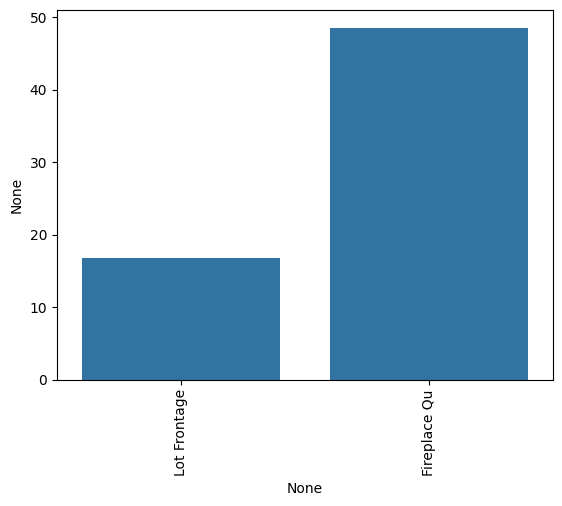

In [ ]:
# Do Not Run this

**Filling in Fireplace Quality based on Description Text**

Let's look at the unique values of 'Fireplace Qu'

In [ ]:
# Do Not Run this

,count
Fireplace Qu,
Gd,741
TA,600
Fa,75
Po,46
Ex,43


They are string values and let's fill the nulls with "None"

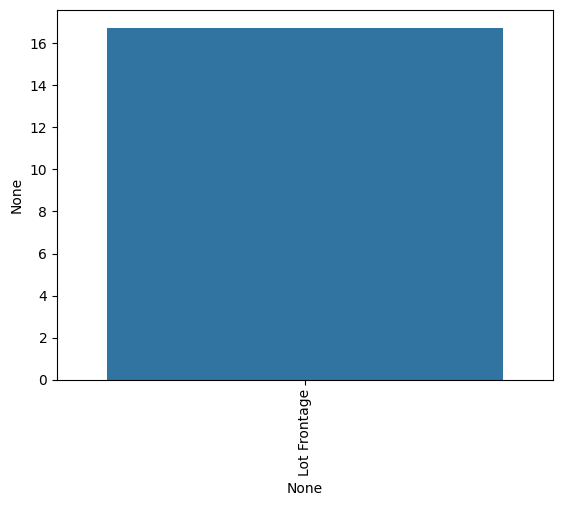

In [ ]:
# Do Not Run this

### **Impute Missing Data based on other Features**

There are more complex methods, but usually the simpler the better, it avoids building models on top of other models.

More Info on Options: https://scikit-learn.org/stable/modules/impute.html

'Lot Frontage' is a numeric feature

LotFrontage: Linear feet of street connected to property

Neighborhood: Physical locations within Ames city limits

In [ ]:
df.groupby('Neighborhood')['Lot Frontage']

In [ ]:
df.groupby('Neighborhood')['Lot Frontage'].mean()

,Lot Frontage
Neighborhood,
Blmngtn,46.900000
Blueste,27.300000
BrDale,21.500000
BrkSide,55.789474
ClearCr,88.150000
CollgCr,71.336364
Crawfor,69.951807
Edwards,64.794286
Gilbert,74.207207


### **Transform Column**

https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.transform.html

In [ ]:
df.head()['Lot Frontage']

,Lot Frontage
0,141.0
1,80.0
2,81.0
3,93.0
4,74.0


In [ ]:
df[df['Lot Frontage'].isnull()]

,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Lot Shape,Land Contour,Utilities,Lot Config,Land Slope,...,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
11,20,RL,NaN,7980,Pave,IR1,Lvl,AllPub,Inside,Gtl,...,0,0,0,0,500,3,2010,WD,Normal,185000
14,120,RL,NaN,6820,Pave,IR1,Lvl,AllPub,Corner,Gtl,...,0,0,140,0,0,6,2010,WD,Normal,212000
22,60,FV,NaN,7500,Pave,Reg,Lvl,AllPub,Inside,Gtl,...,0,0,0,0,0,1,2010,WD,Normal,216000
23,20,RL,NaN,11241,Pave,IR1,Lvl,AllPub,CulDSac,Gtl,...,0,0,0,0,700,3,2010,WD,Normal,149000
24,20,RL,NaN,12537,Pave,IR1,Lvl,AllPub,CulDSac,Gtl,...,0,0,0,0,0,4,2010,WD,Normal,149900
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2894,20,RL,NaN,16669,Pave,IR1,Lvl,AllPub,Corner,Gtl,...,0,0,0,0,0,1,2006,WD,Normal,228000
2897,60,RL,NaN,11170,Pave,IR2,Lvl,AllPub,Corner,Gtl,...,0,0,0,0,0,4,2006,WD,Normal,250000
2898,20,RL,NaN,8098,Pave,IR1,Lvl,AllPub,Inside,Gtl,...,0,0,0,0,0,10,2006,WD,Normal,202000
2912,90,RL,NaN,11836,Pave,IR1,Lvl,AllPub,Corner,Gtl,...,0,0,0,0,0,3,2006,WD,Normal,146500


In [ ]:
df.iloc[21:26]['Lot Frontage']

,Lot Frontage
21,85.0
22,NaN
23,NaN
24,NaN
25,65.0


In [ ]:
df.groupby('Neighborhood')['Lot Frontage'].transform(lambda val: val.fillna(val.mean()))

,Lot Frontage
0,141.000000
1,80.000000
2,81.000000
3,93.000000
4,74.000000
...,...
2925,37.000000
2926,75.144444
2927,62.000000
2928,77.000000


In [ ]:
df.groupby('Neighborhood')['Lot Frontage'].transform(lambda val: val.fillna(val.mean())).iloc[21:26]

,Lot Frontage
21,85.000000
22,64.549383
23,75.210667
24,75.210667
25,65.000000


In [ ]:
df['Lot Frontage'] = df.groupby('Neighborhood')['Lot Frontage'].transform(lambda val: val.fillna(val.mean()))

In [ ]:
percent_nan = percent_missing(df)

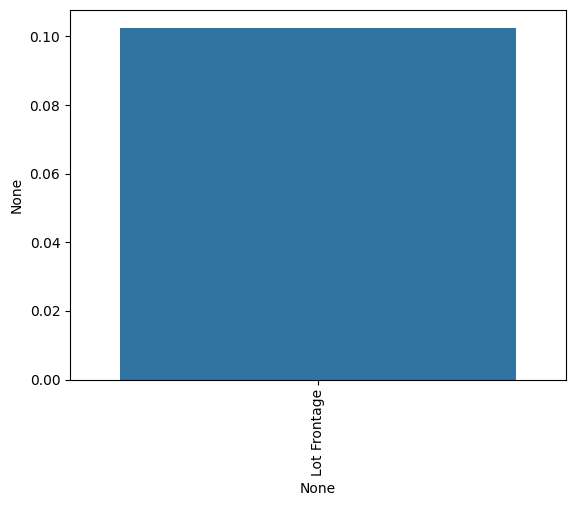

In [ ]:
sns.barplot(x=percent_nan.index,y=percent_nan)
plt.xticks(rotation=90);

In [ ]:
df['Lot Frontage'] = df['Lot Frontage'].fillna(0)

In [ ]:
percent_nan = percent_missing(df)

In [ ]:
percent_nan

,0


Great! We no longer have any missing data in our entire data set! Keep in mind, we should eventually turn all these transformations into an easy to use function. For now, lets' save this dataset:

In [ ]:
df.to_csv("Ames_NO_Missing_Data.csv",index=False)

<br><br>

## **Part 4 - Dealing with Categorical Data**

Many machine learning models can not deal with categorical data set as strings. For example linear regression can not apply a a Beta Coefficent to colors like "red" or "blue". Instead we need to convert these categories into "dummy" variables, otherwise known as "one-hot" encoding.

We will open the .csv file that has been "cleaned" to remove outliers and NaN from the previous lectures.

In [ ]:
df = pd.read_csv("Ames_NO_Missing_Data.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2925 entries, 0 to 2924
Data columns (total 76 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   MS SubClass      2925 non-null   int64  
 1   MS Zoning        2925 non-null   object 
 2   Lot Frontage     2925 non-null   float64
 3   Lot Area         2925 non-null   int64  
 4   Street           2925 non-null   object 
 5   Lot Shape        2925 non-null   object 
 6   Land Contour     2925 non-null   object 
 7   Utilities        2925 non-null   object 
 8   Lot Config       2925 non-null   object 
 9   Land Slope       2925 non-null   object 
 10  Neighborhood     2925 non-null   object 
 11  Condition 1      2925 non-null   object 
 12  Condition 2      2925 non-null   object 
 13  Bldg Type        2925 non-null   object 
 14  House Style      2925 non-null   object 
 15  Overall Qual     2925 non-null   int64  
 16  Overall Cond     2925 non-null   int64  
 17  Year Built    

#### **Numerical Column to Categorical**

We need to be careful when it comes to encoding categories as numbers. We want to make sure that the numerical relationship makes sense for a model. For example, the encoding MSSubClass is essentially just a number code per class:


### **Creating Dummy Variables from Object Columns**

https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.select_dtypes.html

In [ ]:
df.select_dtypes(include='object')

,MS Zoning,Street,Lot Shape,Land Contour,Utilities,Lot Config,Land Slope,Neighborhood,Condition 1,Condition 2,...,Kitchen Qual,Functional,Fireplace Qu,Garage Type,Garage Finish,Garage Qual,Garage Cond,Paved Drive,Sale Type,Sale Condition
0,RL,Pave,IR1,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,...,TA,Typ,Gd,Attchd,Fin,TA,TA,P,WD,Normal
1,RH,Pave,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Feedr,Norm,...,TA,Typ,NaN,Attchd,Unf,TA,TA,Y,WD,Normal
2,RL,Pave,IR1,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,...,Gd,Typ,NaN,Attchd,Unf,TA,TA,Y,WD,Normal
3,RL,Pave,Reg,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,...,Ex,Typ,TA,Attchd,Fin,TA,TA,Y,WD,Normal
4,RL,Pave,IR1,Lvl,AllPub,Inside,Gtl,Gilbert,Norm,Norm,...,TA,Typ,TA,Attchd,Fin,TA,TA,Y,WD,Normal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2920,RL,Pave,IR1,Lvl,AllPub,CulDSac,Gtl,Mitchel,Norm,Norm,...,TA,Typ,NaN,Detchd,Unf,TA,TA,Y,WD,Normal
2921,RL,Pave,IR1,Low,AllPub,Inside,Mod,Mitchel,Norm,Norm,...,TA,Typ,NaN,Attchd,Unf,TA,TA,Y,WD,Normal
2922,RL,Pave,Reg,Lvl,AllPub,Inside,Gtl,Mitchel,Norm,Norm,...,TA,Typ,NaN,NaN,NaN,NaN,NaN,Y,WD,Normal
2923,RL,Pave,Reg,Lvl,AllPub,Inside,Mod,Mitchel,Norm,Norm,...,TA,Typ,TA,Attchd,RFn,TA,TA,Y,WD,Normal


Create separate dfs for including and excluding objects, then show the info of each

In [ ]:
df_nums.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2925 entries, 0 to 2924
Data columns (total 37 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   MS SubClass      2925 non-null   int64  
 1   Lot Frontage     2925 non-null   float64
 2   Lot Area         2925 non-null   int64  
 3   Overall Qual     2925 non-null   int64  
 4   Overall Cond     2925 non-null   int64  
 5   Year Built       2925 non-null   int64  
 6   Year Remod/Add   2925 non-null   int64  
 7   Mas Vnr Area     2925 non-null   float64
 8   BsmtFin SF 1     2925 non-null   float64
 9   BsmtFin SF 2     2925 non-null   float64
 10  Bsmt Unf SF      2925 non-null   float64
 11  Total Bsmt SF    2925 non-null   float64
 12  1st Flr SF       2925 non-null   int64  
 13  2nd Flr SF       2925 non-null   int64  
 14  Low Qual Fin SF  2925 non-null   int64  
 15  Gr Liv Area      2925 non-null   int64  
 16  Bsmt Full Bath   2925 non-null   float64
 17  Bsmt Half Bath

In [ ]:
df_objs.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2925 entries, 0 to 2924
Data columns (total 39 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   MS Zoning       2925 non-null   object
 1   Street          2925 non-null   object
 2   Lot Shape       2925 non-null   object
 3   Land Contour    2925 non-null   object
 4   Utilities       2925 non-null   object
 5   Lot Config      2925 non-null   object
 6   Land Slope      2925 non-null   object
 7   Neighborhood    2925 non-null   object
 8   Condition 1     2925 non-null   object
 9   Condition 2     2925 non-null   object
 10  Bldg Type       2925 non-null   object
 11  House Style     2925 non-null   object
 12  Roof Style      2925 non-null   object
 13  Roof Matl       2925 non-null   object
 14  Exterior 1st    2925 non-null   object
 15  Exterior 2nd    2925 non-null   object
 16  Mas Vnr Type    1152 non-null   object
 17  Exter Qual      2925 non-null   object
 18  Exter Co

### **Converting**

In [ ]:
Create separate dfs for including and excluding objects, then show the info of each

,MS SubClass,Lot Frontage,Lot Area,Overall Qual,Overall Cond,Year Built,Year Remod/Add,Mas Vnr Area,BsmtFin SF 1,BsmtFin SF 2,...,Sale Type_ConLw,Sale Type_New,Sale Type_Oth,Sale Type_VWD,Sale Type_WD,Sale Condition_AdjLand,Sale Condition_Alloca,Sale Condition_Family,Sale Condition_Normal,Sale Condition_Partial
0,20,141.000000,31770,6,5,1960,1960,112.0,639.0,0.0,...,False,False,False,False,True,False,False,False,True,False
1,20,80.000000,11622,5,6,1961,1961,0.0,468.0,144.0,...,False,False,False,False,True,False,False,False,True,False
2,20,81.000000,14267,6,6,1958,1958,108.0,923.0,0.0,...,False,False,False,False,True,False,False,False,True,False
3,20,93.000000,11160,7,5,1968,1968,0.0,1065.0,0.0,...,False,False,False,False,True,False,False,False,True,False
4,60,74.000000,13830,5,5,1997,1998,0.0,791.0,0.0,...,False,False,False,False,True,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2920,80,37.000000,7937,6,6,1984,1984,0.0,819.0,0.0,...,False,False,False,False,True,False,False,False,True,False
2921,20,75.144444,8885,5,5,1983,1983,0.0,301.0,324.0,...,False,False,False,False,True,False,False,False,True,False
2922,85,62.000000,10441,5,5,1992,1992,0.0,337.0,0.0,...,False,False,False,False,True,False,False,False,True,False
2923,20,77.000000,10010,5,5,1974,1975,0.0,1071.0,123.0,...,False,False,False,False,True,False,False,False,True,False


## Final Thoughts

Keep in mind, we don't know if 274 columns is very useful. More columns doesn't necessarily lead to better results. In fact, we may want to further remove columns (or later on use a model with regularization to choose important columns for us). What we have done here has greatly expanded the ratio of rows to columns, which may actually lead to worse performance (however you don't know until you've actually compared multiple models/approaches).

In [ ]:
final_df.corr()['SalePrice'].sort_values()

,SalePrice
Exter Qual_TA,-0.591459
Kitchen Qual_TA,-0.527461
Bsmt Qual_TA,-0.453022
Garage Finish_Unf,-0.422363
Garage Type_Detchd,-0.365209
...,...
Garage Cars,0.648488
Total Bsmt SF,0.660983
Gr Liv Area,0.727279
Overall Qual,0.802637


    OverallQual: Rates the overall material and finish of the house

           10	Very Excellent
           9	Excellent
           8	Very Good
           7	Good
           6	Above Average
           5	Average
           4	Below Average
           3	Fair
           2	Poor
           1	Very Poor

Most likely a human realtor rated this "Overall Qual" column, which means it highly likely takes into account many of the other features. It also means that any future house we intend to predict a price for will need this "Overall Qual" feature, which implies that every new house on the market that will be priced with our ML model will still require a human person!

In [ ]:
final_df.to_csv('AMES_Final_DF.csv')